# Modelo de clasificación de Imágenes de One Piece
### Arturo Sánchez Rodríguez | A01275427

In [2]:
#Importar las librerías que vamos a utilizar en el proyecto de clasificación de imágenes
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping)

In [3]:

onePiece_data = "OnePiece/Data/Data" #Definimos la ruta de nuestro dataset para luego poder llamarlo
print(os.listdir("OnePiece/Data/Data/")[::]) #Vemos las clases que tenemos en nuestro dataset

#A diferencia con el dataset de MNIST que ya tiene las imágenes convertidas en números y listas para ser utilizadas, con nuestro modelo no esta asi entonces como la computadora no puede ver las imágenes tenemos que convertirlos en números.

def cargar_img(path, img_size=(64, 64)):
    images = []
    labels = []

    class_names = sorted([
        clase for clase in os.listdir(path)
        if os.path.isdir(os.path.join(path, clase))
    ])

    for label_index, class_name in enumerate(class_names):
        class_path = os.path.join(path, class_name)
        for file_name in os.listdir(class_path):
            if file_name.lower().endswith((".png", ".jpg", "jpeg")):
                img_path = os.path.join(class_path, file_name)
                img = tf.keras.utils.load_img(img_path, target_size=img_size)
                img_array = tf.keras.utils.img_to_array(img)
                images.append(img_array)
                labels.append(label_index)
    images = np.array(images)
    labels = np.array(labels)

    return images, labels, class_names

images, labels, class_names = cargar_img(onePiece_data)

#Imprimimos la forma de las imágenes, etiquetas, nombres de clases y la cantidad de clases para verificar que todo se haya cargado correctamente
print(images.shape)
print(labels.shape)
print(class_names)
print(len(class_names))


['Akainu', '.DS_Store', 'Sanji', 'Jinbei', 'Nami', 'Law', 'Crocodile', 'Mihawk', 'Chopper', 'Zoro', 'Shanks', 'Brook', 'Rayleigh', 'Usopp', 'Kurohige', 'Franky', 'Ace', 'Luffy', 'Robin']


/Users/arturosr/Library/Python/3.11/lib/python/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


(11737, 64, 64, 3)
(11737,)
['Ace', 'Akainu', 'Brook', 'Chopper', 'Crocodile', 'Franky', 'Jinbei', 'Kurohige', 'Law', 'Luffy', 'Mihawk', 'Nami', 'Rayleigh', 'Robin', 'Sanji', 'Shanks', 'Usopp', 'Zoro']
18


In [4]:
#Separamos el dataset en TRAIN y TEST
train_img, test_img, train_labels, test_labels = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train imágenes:", train_img.shape)
print("Test imágenes:", test_img.shape)
print("Train labels:", train_labels.shape)
print("Test labels:", test_labels.shape)

Train imágenes: (9389, 64, 64, 3)
Test imágenes: (2348, 64, 64, 3)
Train labels: (9389,)
Test labels: (2348,)


In [5]:

def scale_img(train_img, test_img):
    train_img = train_img / 255.
    test_img = test_img / 255.
    return train_img, test_img



train_img, test_img = scale_img(train_img, test_img)

print("train_img.shape:", train_img.shape)
print("test_img.shape:", test_img.shape)
print("train_img.min():", train_img.min(), "train_img.max():", train_img.max())
print("test_img.min():", test_img.min(), "test_img.max():", test_img.max())

train_img.shape: (9389, 64, 64, 3)
test_img.shape: (2348, 64, 64, 3)
train_img.min(): 0.0 train_img.max(): 1.0
test_img.min(): 0.0 test_img.max(): 1.0


In [6]:
np.save("train_img.npy", train_img)
np.save("test_img.npy", test_img)

np.save("train_labels.npy", train_labels)
np.save("test_labels.npy", test_labels)

np.save("class_names.npy", class_names)

print("Se guardaron los test y train en formato .npy de manera correcta!")

Se guardaron los test y train en formato .npy de manera correcta!


# Modelo

In [7]:
#Tenemos que definir cuántas clases tiene nuestro dataset

num_classes = len(class_names)
print("Número de clases:", num_classes)
print("Clases:", class_names)

Número de clases: 18
Clases: ['Ace', 'Akainu', 'Brook', 'Chopper', 'Crocodile', 'Franky', 'Jinbei', 'Kurohige', 'Law', 'Luffy', 'Mihawk', 'Nami', 'Rayleigh', 'Robin', 'Sanji', 'Shanks', 'Usopp', 'Zoro']


In [8]:
#implementamos data augmentation para mejorar el rendimiento del modelo 2 CNN y evitar overfitting

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
    layers.RandomFlip("vertical")
])


In [9]:
def get_model_CNN_V2(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,

        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        
        layers.Conv2D(256, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),

        layers.Dense(num_classes, activation="softmax")
    ])

    return model
model_cnn_v2 = get_model_CNN_V2(input_shape=(64, 64, 3), num_classes=num_classes)
model_cnn_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 915,154 (3.49 MB)

 Trainable params: 915,154 (3.49 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
def compile_model(model):
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

compile_model(model_cnn_v2)

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_best = ModelCheckpoint(
    filepath="best_model.keras", 
    monitor="val_accuracy", 
    save_best_only=True, 
    verbose=0
)

In [12]:
def train_model(model, train_img, train_labels):
    history = model.fit(train_img, train_labels, validation_split=0.2, epochs=50, batch_size=64, callbacks=[checkpoint_best])
    return history

history = train_model(model_cnn_v2, train_img, train_labels)

Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.0839 - loss: 2.8250 - val_accuracy: 0.0932 - val_loss: 3.1671
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.1445 - loss: 2.6596 - val_accuracy: 0.1374 - val_loss: 2.8178
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.1775 - loss: 2.5708 - val_accuracy: 0.1741 - val_loss: 2.6343
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.2110 - loss: 2.4576 - val_accuracy: 0.1991 - val_loss: 2.6355
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.2482 - loss: 2.3703 - val_accuracy: 0.2577 - val_loss: 2.4296
Epoch 6/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.3026 - loss: 2.2295 - val_accuracy: 0.2806 - val_loss: 2.4912
Epoch 7/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.3470 - loss: 2.0990 - val_accuracy: 0.3275 - val_loss: 2.2423
Epoch 8/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.3897 - loss: 1.9791 - val_accu

In [13]:
#Evaluamos el modelo con el set de prueba
test_loss, test_accuracy = model_cnn_v2.evaluate(test_img, test_labels)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6376 - loss: 1.4601
Test loss: 1.4600722789764404
Test accuracy: 0.6375638842582703


In [14]:
# Resultados 

print(history.history["accuracy"][-1])
print(history.history["val_accuracy"][-1])

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)


0.805618405342102
0.636847734451294
Test accuracy: 0.6375638842582703
Test loss: 1.4600722789764404


In [15]:
#Vamos a calcular otras métricas de evaluación como precisión, recall, F1-score y matriz de confusión para tener una visión más completa del rendimiento del modelo.
y_pred_probs = model_cnn_v2.predict(test_img)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = test_labels
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

accuracy = accuracy_score(test_labels, y_pred_classes)
precision = precision_score(test_labels, y_pred_classes, average="weighted")
recall = recall_score(test_labels, y_pred_classes, average="weighted")
f1 = f1_score(test_labels, y_pred_classes, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Accuracy : 0.6375638841567292
Precision: 0.6743179250377328
Recall   : 0.6375638841567292
F1 Score : 0.6426154518636649


In [16]:

#Creamos un DataFrame para poder visualizar mejor las métricas de nuestro modelo
results_cnn_v2 = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100
    ]
})

results_cnn_v2["Value"] = results_cnn_v2["Value"].round(2)

results_cnn_v2

,Metric,Value
0,Accuracy,63.76
1,Precision,67.43
2,Recall,63.76
3,F1 Score,64.26


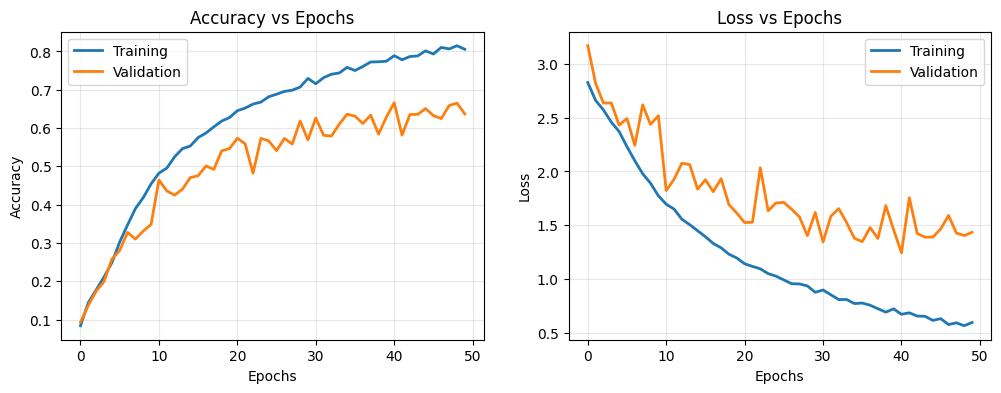

In [17]:
frame = pd.DataFrame(history.history)

train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(train_acc, label="Training", linewidth=2)
plt.plot(val_acc, label="Validation", linewidth=2)
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(train_loss, label="Training", linewidth=2)
plt.plot(val_loss, label="Validation", linewidth=2)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

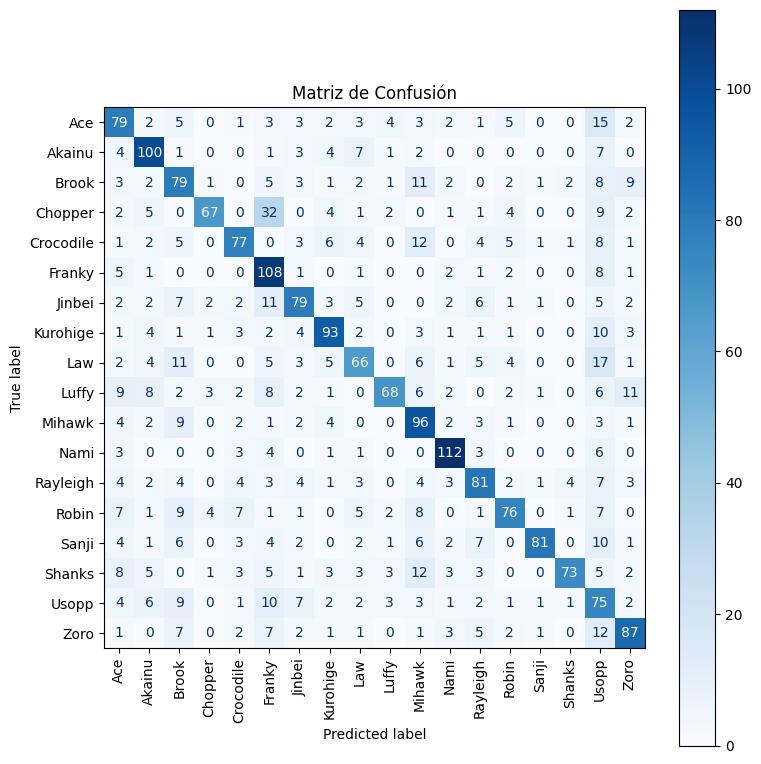

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels, y_pred_classes)
fig , ax = plt.subplots(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=True)
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.show()

## Guardar el Modelo

In [19]:
model_cnn_v2.save("onepiece_model.keras")
print("Modelo guardado correctamente!")


#Asi se recupera el modelo que se guardo
"""
loaded_model = tf.keras.models.load_model(
    "onepiece_model.keras"
)
"""

Modelo guardado correctamente!


'\nloaded_model = tf.keras.models.load_model(\n    "onepiece_model.keras"\n)\n'